# Final ToM Results Review (Apr 8)

This notebook is for stable local analysis of the finalized auxhead-lite artifacts.

It avoids live Modal volume access and focuses on:
- the archived 800-episode auxhead-lite incumbent,
- the original 800-run seed 7 vs seed 11 qualitative figures,
- the consolidated `130k` report pack,
- the consolidated `140k` long-run report pack,
- final cross-checkpoint comparison and recommendation.


In [12]:
import json
from pathlib import Path

try:
    from IPython.display import Image, Markdown, SVG, display
except ImportError:
    class _DisplayObject:
        def __init__(self, *args, **kwargs):
            self.args = args
            self.kwargs = kwargs

        def __repr__(self):
            label = self.__class__.__name__
            payload = self.kwargs if self.kwargs else self.args
            return f"<{label} {payload}>"

    class Image(_DisplayObject):
        pass

    class Markdown(_DisplayObject):
        pass

    class SVG(_DisplayObject):
        pass

    def display(*objects):
        for obj in objects:
            print(obj)

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

ROOT = Path("/Users/stephenbeale/Projects/ToM AI Research Team")
CURRENT_INCUMBENT_FILE = ROOT / "modal" / "tom-experiment-incumbent" / "CURRENT_INCUMBENT.txt"
ARCHIVED_INCUMBENT_ROOT = ROOT / "modal" / "tom-experiment-incumbent" / "auxhead-lite"
INITIAL_800_ROOT = ROOT / "modal" / "initial-800-run-analysis"
RESULTS_130_ROOT = ROOT / "modal" / "tom-130k-modal-results"
REPORTS_130_ROOT = RESULTS_130_ROOT / "reports"
RESULTS_140_ROOT = ROOT / "modal" / "tom-140k-modal-results"
REPORTS_140_ROOT = RESULTS_140_ROOT / "reports"

SEEDS = [7, 11]
METRIC_ORDER = [
    "ToMCoordScore",
    "SuccessRate",
    "DeadlockRate",
    "CollisionRate",
    "IntentionPredictionF1",
    "StrategySwitchAccuracy",
    "AmbiguityEfficiency",
    "CoordinationEfficiency",
    "AverageDelay",
]


def load_json(path: Path):
    return json.loads(path.read_text())


def load_text(path: Path):
    return path.read_text()


def as_table(rows, index=None, sort_by=None, ascending=False):
    if pd is None:
        return rows
    df = pd.DataFrame(rows)
    if sort_by is not None:
        df = df.sort_values(sort_by, ascending=ascending)
    if index is not None:
        df = df.set_index(index)
    return df


def display_svg(path: Path):
    display(SVG(filename=str(path)))


def display_png(path: Path, width: int = 1100):
    display(Image(filename=str(path), width=width))


In [13]:
current_incumbent = load_text(CURRENT_INCUMBENT_FILE).strip()

old_selection = {
    seed: load_json(ARCHIVED_INCUMBENT_ROOT / f"seed{seed}" / "selection.json")
    for seed in SEEDS
}
run_130 = {
    seed: load_json(RESULTS_130_ROOT / f"seed{seed}" / "target-130000" / "run_summary.json")
    for seed in SEEDS
}
run_140 = {
    seed: load_json(RESULTS_140_ROOT / f"seed{seed}" / "target-140000" / "run_summary.json")
    for seed in SEEDS
}
summary_130 = load_json(REPORTS_130_ROOT / "modal_130k_summary.json")
summary_140 = load_json(REPORTS_140_ROOT / "modal_longrun_summary.json")

display(Markdown(f"**Current archived incumbent pointer:** `{current_incumbent}`"))


**Current archived incumbent pointer:** `/Users/stephenbeale/Projects/ToM experiment incumbent/auxhead-lite`

In [14]:
summary_rows = [
    {"checkpoint": "130k", "loaded_seeds": len(run_130)},
    {"checkpoint": "140k", "loaded_seeds": len(run_140)},
]

display(Markdown("### Loaded summary bundles"))
display(as_table(summary_rows, index="checkpoint"))

### Loaded summary bundles

,loaded_seeds
checkpoint,
130k,2
140k,2


In [15]:
artifact_rows = [
    {"artifact": "Current incumbent pointer", "path": str(CURRENT_INCUMBENT_FILE), "exists": CURRENT_INCUMBENT_FILE.exists()},
    {"artifact": "Archived auxhead-lite seed7 selection", "path": str(ARCHIVED_INCUMBENT_ROOT / "seed7" / "selection.json"), "exists": (ARCHIVED_INCUMBENT_ROOT / "seed7" / "selection.json").exists()},
    {"artifact": "Archived auxhead-lite seed11 selection", "path": str(ARCHIVED_INCUMBENT_ROOT / "seed11" / "selection.json"), "exists": (ARCHIVED_INCUMBENT_ROOT / "seed11" / "selection.json").exists()},
    {"artifact": "Initial 800-run image folder", "path": str(INITIAL_800_ROOT), "exists": INITIAL_800_ROOT.exists()},
    {"artifact": "130k verdict", "path": str(REPORTS_130_ROOT / "modal_130k_verdict.md"), "exists": (REPORTS_130_ROOT / "modal_130k_verdict.md").exists()},
    {"artifact": "130k summary", "path": str(REPORTS_130_ROOT / "modal_130k_summary.json"), "exists": (REPORTS_130_ROOT / "modal_130k_summary.json").exists()},
    {"artifact": "140k verdict", "path": str(REPORTS_140_ROOT / "modal_longrun_verdict.md"), "exists": (REPORTS_140_ROOT / "modal_longrun_verdict.md").exists()},
    {"artifact": "140k summary", "path": str(REPORTS_140_ROOT / "modal_longrun_summary.json"), "exists": (REPORTS_140_ROOT / "modal_longrun_summary.json").exists()},
]

run_metadata_rows = []
for seed in SEEDS:
    for checkpoint, summary in [("130k", run_130[seed]), ("140k", run_140[seed])]:
        run_metadata_rows.append(
            {
                "seed": seed,
                "checkpoint": checkpoint,
                "target_total_episodes": summary["target_total_episodes"],
                "additional_train_episodes": summary["additional_train_episodes"],
                "initial_checkpoint_train_episodes": summary["initial_checkpoint_train_episodes"],
                "returncode": summary["returncode"],
                "saved_checkpoint": summary["saved_checkpoint"],
            }
        )

display(Markdown("### Artifact inventory"))
display(as_table(artifact_rows))
display(Markdown("### Final run metadata"))
display(as_table(run_metadata_rows, sort_by=["seed", "checkpoint"], ascending=True))


### Artifact inventory

,artifact,path,exists
0,Current incumbent pointer,/Users/stephenbeale/Projects/ToM AI Research T...,True
1,Archived auxhead-lite seed7 selection,/Users/stephenbeale/Projects/ToM AI Research T...,True
2,Archived auxhead-lite seed11 selection,/Users/stephenbeale/Projects/ToM AI Research T...,True
3,Initial 800-run image folder,/Users/stephenbeale/Projects/ToM AI Research T...,True
4,130k verdict,/Users/stephenbeale/Projects/ToM AI Research T...,True
5,130k summary,/Users/stephenbeale/Projects/ToM AI Research T...,True
6,140k verdict,/Users/stephenbeale/Projects/ToM AI Research T...,True
7,140k summary,/Users/stephenbeale/Projects/ToM AI Research T...,True


### Final run metadata

,seed,checkpoint,target_total_episodes,additional_train_episodes,initial_checkpoint_train_episodes,returncode,saved_checkpoint
0,7,130k,130000,129200,800,0,/root/outputs/auxhead-lite/seed7/target-130000...
1,7,140k,140000,139200,800,0,/root/outputs/auxhead-lite/seed7/target-140000...
2,11,130k,130000,129200,800,0,/root/outputs/auxhead-lite/seed11/target-13000...
3,11,140k,140000,139200,800,0,/root/outputs/auxhead-lite/seed11/target-14000...


## Archived 800-Episode Incumbent Context

These are the saved auxhead-lite selections promoted from the initial local 800-episode pass. This gives the baseline context before the longer Modal continuations.


In [16]:
incumbent_rows = []
for seed in SEEDS:
    selection = old_selection[seed]
    candidate = selection["candidate_metrics"]
    baseline = selection["baseline_metrics"]
    incumbent_rows.append(
        {
            "seed": seed,
            "decision": selection["decision"],
            "selected_variant": selection["selected_variant"],
            "ToMCoordScore": candidate["ToMCoordScore"],
            "score_gain_vs_baseline": candidate["ToMCoordScore"] - baseline["ToMCoordScore"],
            "SuccessRate": candidate["SuccessRate"],
            "DeadlockRate": candidate["DeadlockRate"],
            "CollisionRate": candidate["CollisionRate"],
            "IntentionPredictionF1": candidate["IntentionPredictionF1"],
            "StrategySwitchAccuracy": candidate["StrategySwitchAccuracy"],
            "AmbiguityEfficiency": candidate["AmbiguityEfficiency"],
            "AverageDelay": candidate["AverageDelay"],
        }
    )

as_table(incumbent_rows, index="seed")


,decision,selected_variant,ToMCoordScore,score_gain_vs_baseline,SuccessRate,DeadlockRate,CollisionRate,IntentionPredictionF1,StrategySwitchAccuracy,AmbiguityEfficiency,AverageDelay
seed,,,,,,,,,,,
7,keep,tom,0.168767,0.228567,0.35,0.5,0.15,0.445480,0.85,0.1250,12.15
11,keep,tom,0.124564,0.195964,0.30,0.5,0.20,0.455811,0.85,0.0875,11.80


In [17]:
display(Markdown("Archived incumbent selections and long-run summaries are loaded for both seeds."))

Archived incumbent selections and long-run summaries are loaded for both seeds.

## Initial 800-Run Qualitative Figures

These are the preserved seed 7 vs seed 11 figures from the initial local 800-episode comparison. They now live in the repo instead of the Desktop copy.


### Belief transitions (counts)

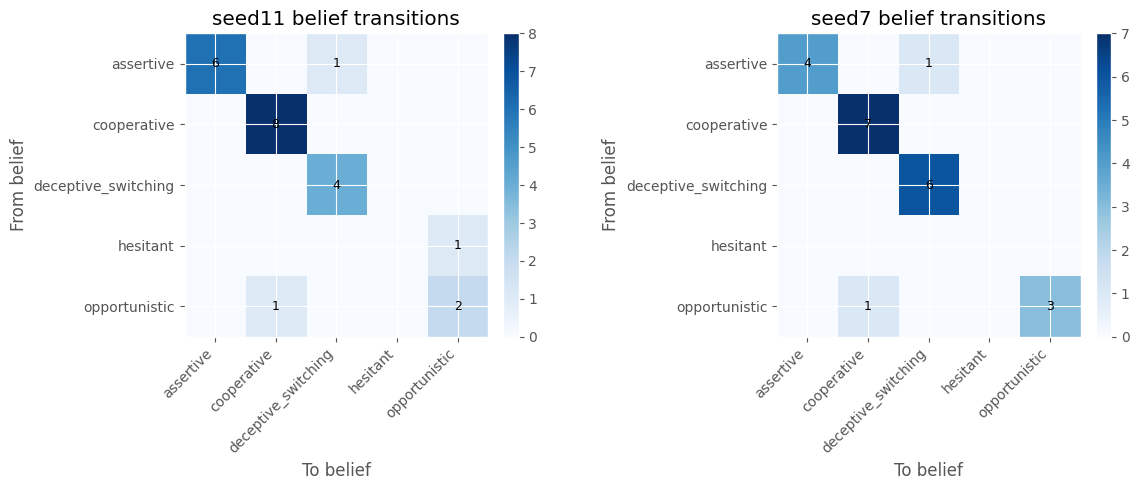

### Belief transitions (normalized)

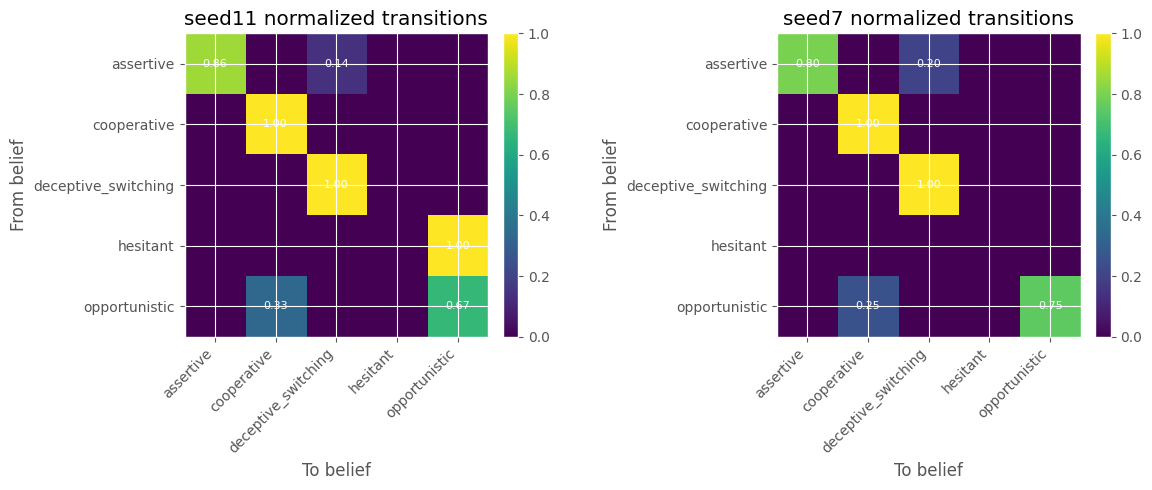

### Normalized transition delta (seed11 - seed7)

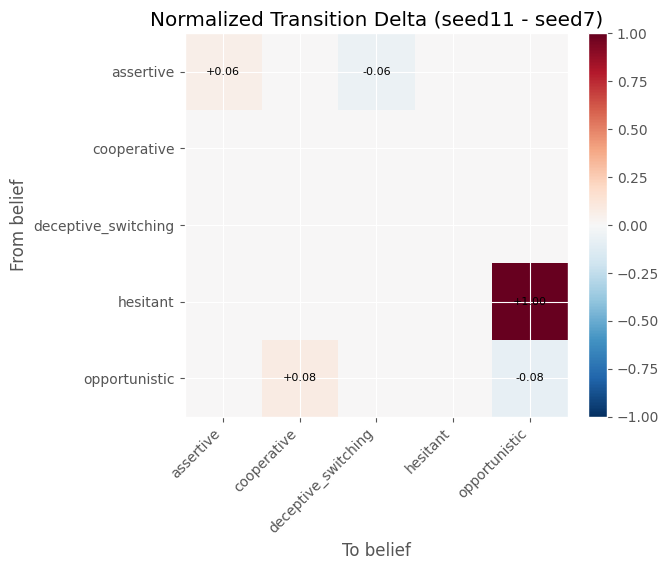

### Mean belief confidence by step index

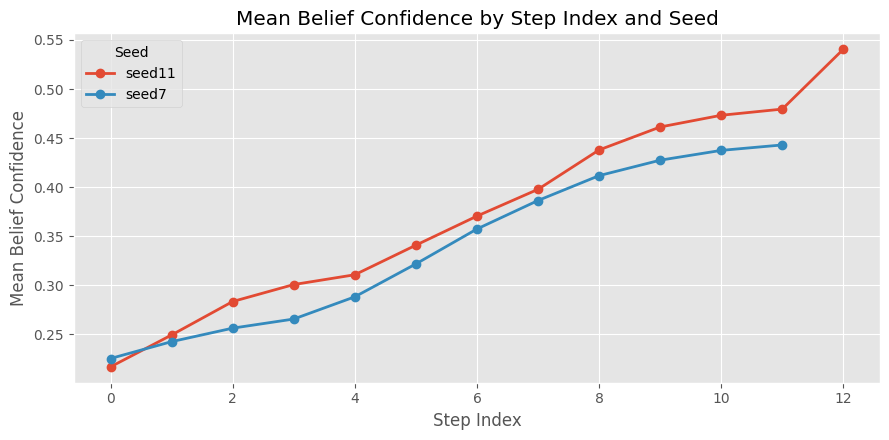

### Outcome rate by seed

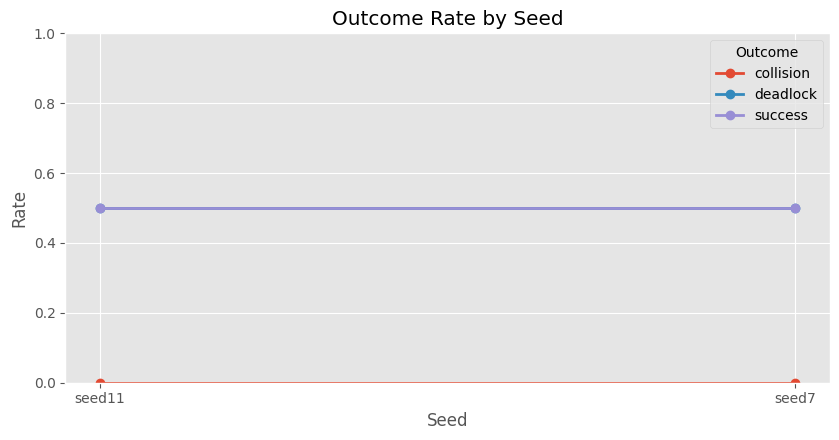

### Action distribution by seed

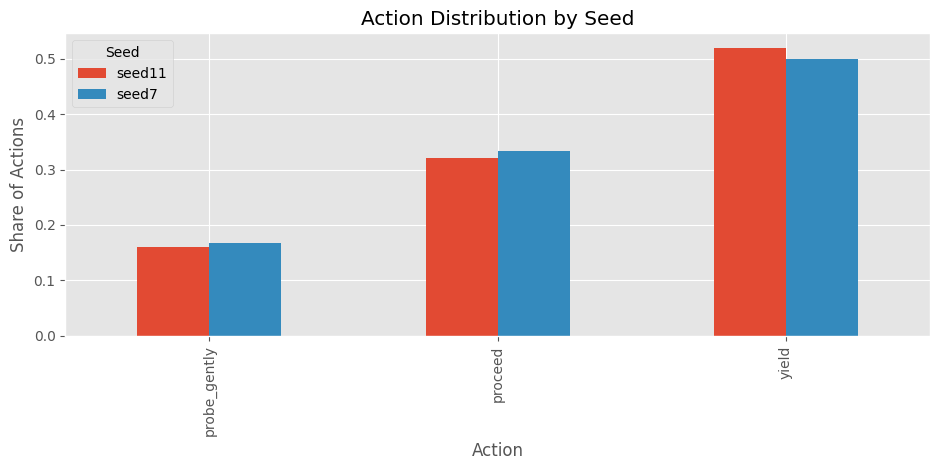

In [18]:
initial_800_figures = [
    ("Belief transitions (counts)", "belief-change-heatmap.png"),
    ("Belief transitions (normalized)", "normalised transitions heatmap.png"),
    ("Normalized transition delta (seed11 - seed7)", "normalised-transition-delta-seed-7-11.png"),
    ("Mean belief confidence by step index", "mean-belief-confidence-by-seed.png"),
    ("Outcome rate by seed", "outcome-rate-by-seed.png"),
    ("Action distribution by seed", "action-distribution-by-seed.png"),
]

for title, filename in initial_800_figures:
    display(Markdown(f"### {title}"))
    display_png(INITIAL_800_ROOT / filename)


## Cross-Checkpoint Metric Table

This puts the archived 800-episode incumbent beside the final `130k` and `140k` checkpoints for each seed.


In [19]:
checkpoint_rows = []
for seed in SEEDS:
    checkpoint_rows.append(
        {
            "seed": seed,
            "checkpoint": "old_auxhead_800",
            **{metric: old_selection[seed]["candidate_metrics"][metric] for metric in METRIC_ORDER},
        }
    )
    checkpoint_rows.append(
        {
            "seed": seed,
            "checkpoint": "130k",
            **{metric: run_130[seed]["eval_metrics"][metric] for metric in METRIC_ORDER},
        }
    )
    checkpoint_rows.append(
        {
            "seed": seed,
            "checkpoint": "140k",
            **{metric: run_140[seed]["eval_metrics"][metric] for metric in METRIC_ORDER},
        }
    )

if pd is None:
    checkpoint_rows
else:
    pd.DataFrame(checkpoint_rows).sort_values(["seed", "checkpoint"]).set_index(["seed", "checkpoint"])


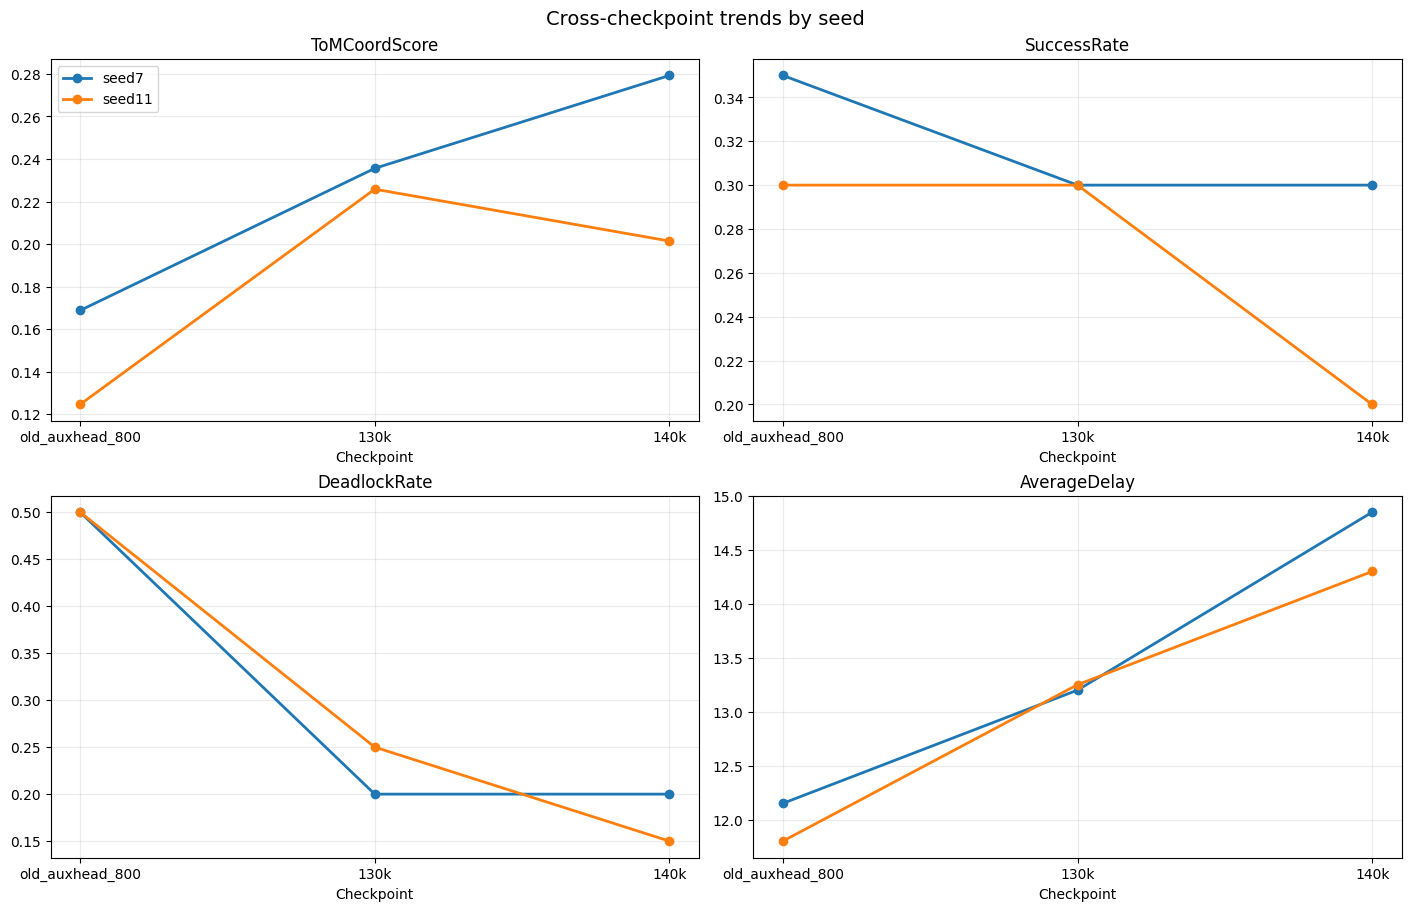

In [20]:
if plt is None or pd is None:
    display(Markdown("Install `matplotlib` and `pandas` to render inline comparison graphs."))
else:
    checkpoint_order = ["old_auxhead_800", "130k", "140k"]
    metrics_to_plot = ["ToMCoordScore", "SuccessRate", "DeadlockRate", "AverageDelay"]
    plot_df = pd.DataFrame(checkpoint_rows)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    for ax, metric in zip(axes.flatten(), metrics_to_plot):
        for seed in SEEDS:
            subset = plot_df[plot_df["seed"] == seed].set_index("checkpoint")
            y_values = [subset.loc[cp, metric] for cp in checkpoint_order]
            ax.plot(checkpoint_order, y_values, marker="o", linewidth=2, label=f"seed{seed}")
        ax.set_title(metric)
        ax.set_xlabel("Checkpoint")
        ax.grid(alpha=0.25)

    axes[0, 0].legend(loc="best")
    fig.suptitle("Cross-checkpoint trends by seed", fontsize=14)
    display(fig)
    plt.close(fig)

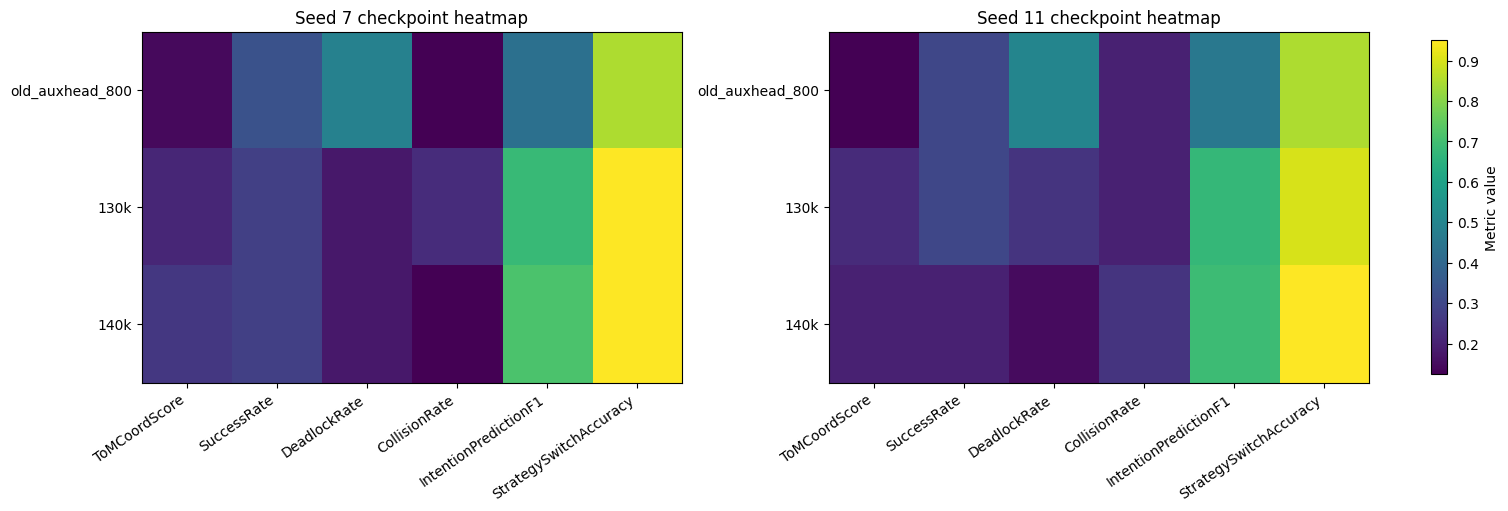

In [29]:
if plt is None or pd is None:
    display(Markdown("Install `matplotlib` and `pandas` to render heatmaps."))
else:
    heatmap_metrics = [
        "ToMCoordScore",
        "SuccessRate",
        "DeadlockRate",
        "CollisionRate",
        "IntentionPredictionF1",
        "StrategySwitchAccuracy",
    ]
    checkpoint_order = ["old_auxhead_800", "130k", "140k"]
    checkpoint_df = pd.DataFrame(checkpoint_rows)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    for ax, seed in zip(axes, SEEDS):
        pivot = (
            checkpoint_df[checkpoint_df["seed"] == seed]
            .set_index("checkpoint")
            .loc[checkpoint_order, heatmap_metrics]
        )
        image = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
        ax.set_title(f"Seed {seed} checkpoint heatmap")
        ax.set_xticks(range(len(heatmap_metrics)))
        ax.set_xticklabels(heatmap_metrics, rotation=35, ha="right")
        ax.set_yticks(range(len(checkpoint_order)))
        ax.set_yticklabels(checkpoint_order)

    cbar = fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.set_label("Metric value")
    display(fig)
    plt.close(fig)

## 130k Consolidated Branch

This is the safer cross-seed stopping point from the long-run continuation work.


In [21]:
display(Markdown(load_text(REPORTS_130_ROOT / "modal_130k_verdict.md")))

branch_130_rows = [
    {"metric": metric, "branch_mean_130k": summary_130["branch_mean_metrics"][metric]}
    for metric in METRIC_ORDER
]

seed_130_delta_rows = []
for seed in SEEDS:
    delta_block = summary_130[f"seed{seed}_vs_old_auxhead"]
    for metric in METRIC_ORDER:
        seed_130_delta_rows.append(
            {
                "seed": seed,
                "metric": metric,
                "old_auxhead_800": delta_block[metric]["old"],
                "candidate_130k": delta_block[metric]["new"],
                "delta_130k_minus_old": delta_block[metric]["delta"],
            }
        )

display(Markdown("### Branch mean metrics"))
display(as_table(branch_130_rows, index="metric"))
display(Markdown("### 130k vs archived auxhead-lite by seed"))
display(as_table(seed_130_delta_rows))


# Modal 130k Verdict

- Old auxhead-lite incumbents: Discard as current best; keep as archive baselines.
- Seed7 130k: Keep. Best single run in the branch.
- Seed11 130k: Keep. Supporting replicate with slightly rougher ambiguity handling.
- Branch as a whole: Keep as the current best candidate branch. Strong enough to supersede the old 800-episode auxhead-lite line, but not yet a fully clean behavioral endpoint.

## Branch Mean Metrics
- ToMCoordScore: 0.2307
- SuccessRate: 0.3000
- DeadlockRate: 0.2250
- CollisionRate: 0.2250
- IntentionPredictionF1: 0.6825
- StrategySwitchAccuracy: 0.9250
- AmbiguityEfficiency: 0.1063
- CoordinationEfficiency: 0.0887
- AverageDelay: 13.2250

## Seed7 130k vs Old Auxhead-Lite Seed7
- ToMCoordScore: 0.2356 vs 0.1688 (+0.0668 (better))
- SuccessRate: 0.3000 vs 0.3500 (-0.0500 (worse))
- DeadlockRate: 0.2000 vs 0.5000 (-0.3000 (better))
- CollisionRate: 0.2500 vs 0.1500 (+0.1000 (worse))
- IntentionPredictionF1: 0.6900 vs 0.4455 (+0.2445 (better))
- StrategySwitchAccuracy: 0.9500 vs 0.8500 (+0.1000 (better))
- AmbiguityEfficiency: 0.1208 vs 0.1250 (-0.0042 (worse))
- CoordinationEfficiency: 0.0925 vs 0.0900 (+0.0025 (better))
- AverageDelay: 13.2000 vs 12.1500 (+1.0500 (worse))

## Seed11 130k vs Old Auxhead-Lite Seed11
- ToMCoordScore: 0.2258 vs 0.1246 (+0.1012 (better))
- SuccessRate: 0.3000 vs 0.3000 (+0.0000 (better))
- DeadlockRate: 0.2500 vs 0.5000 (-0.2500 (better))
- CollisionRate: 0.2000 vs 0.2000 (+0.0000 (better))
- IntentionPredictionF1: 0.6751 vs 0.4558 (+0.2193 (better))
- StrategySwitchAccuracy: 0.9000 vs 0.8500 (+0.0500 (better))
- AmbiguityEfficiency: 0.0917 vs 0.0875 (+0.0042 (better))
- CoordinationEfficiency: 0.0850 vs 0.0700 (+0.0150 (better))
- AverageDelay: 13.2500 vs 11.8000 (+1.4500 (worse))

## Charts
- `metric_comparison.svg`
- `curve_overlay.svg`
- `family_outcome_grid.svg`


### Branch mean metrics

,branch_mean_130k
metric,
ToMCoordScore,0.230706
SuccessRate,0.300000
DeadlockRate,0.225000
CollisionRate,0.225000
IntentionPredictionF1,0.682540
StrategySwitchAccuracy,0.925000
AmbiguityEfficiency,0.106250
CoordinationEfficiency,0.088750
AverageDelay,13.225000


### 130k vs archived auxhead-lite by seed

,seed,metric,old_auxhead_800,candidate_130k,delta_130k_minus_old
0,7,ToMCoordScore,0.168767,0.235599,0.066832
1,7,SuccessRate,0.350000,0.300000,-0.050000
2,7,DeadlockRate,0.500000,0.200000,-0.300000
3,7,CollisionRate,0.150000,0.250000,0.100000
4,7,IntentionPredictionF1,0.445480,0.689992,0.244512
5,7,StrategySwitchAccuracy,0.850000,0.950000,0.100000
6,7,AmbiguityEfficiency,0.125000,0.120833,-0.004167
7,7,CoordinationEfficiency,0.090000,0.092500,0.002500
8,7,AverageDelay,12.150000,13.200000,1.050000
9,11,ToMCoordScore,0.124564,0.225812,0.101249


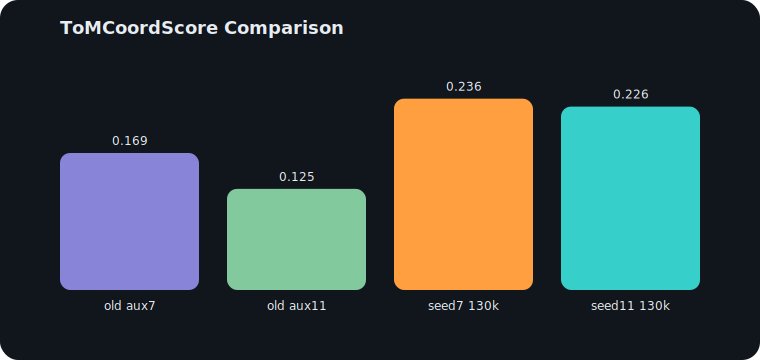

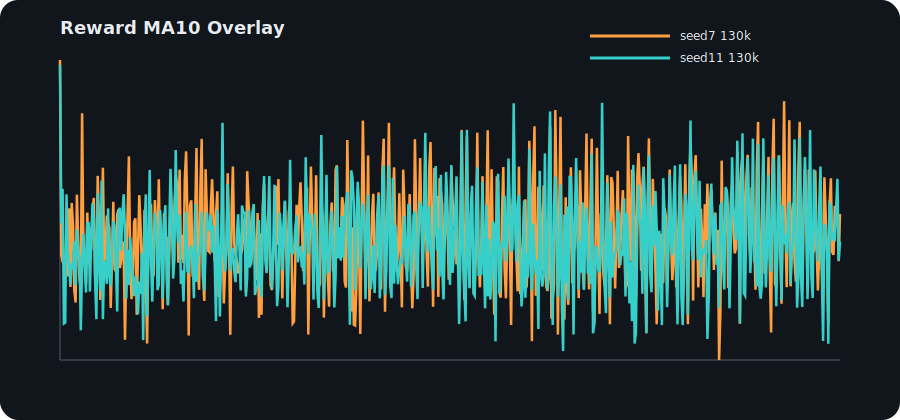

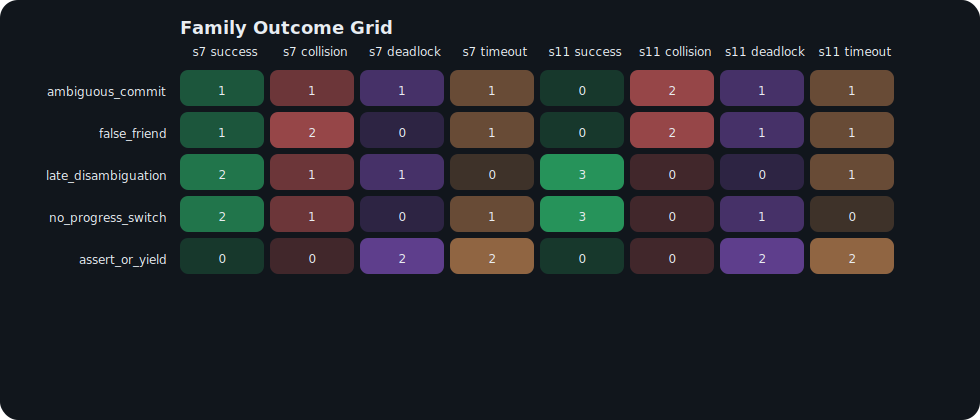

In [22]:
display_svg(REPORTS_130_ROOT / "metric_comparison.svg")
display_svg(REPORTS_130_ROOT / "curve_overlay.svg")
display_svg(REPORTS_130_ROOT / "family_outcome_grid.svg")


In [23]:
delta_130_seed7 = summary_130["seed7_vs_old_auxhead"]["ToMCoordScore"]["delta"]
delta_130_seed11 = summary_130["seed11_vs_old_auxhead"]["ToMCoordScore"]["delta"]
mean_130_score = summary_130["branch_mean_metrics"]["ToMCoordScore"]
mean_130_success = summary_130["branch_mean_metrics"]["SuccessRate"]

takeaways_130 = [
    "### 130k report quick read",
    f"- Mean branch ToMCoordScore at 130k: `{mean_130_score:.3f}`.",
    f"- Mean branch SuccessRate at 130k: `{mean_130_success:.3f}`.",
    f"- Seed 7 ToMCoordScore delta vs archived 800: `{delta_130_seed7:+.3f}`.",
    f"- Seed 11 ToMCoordScore delta vs archived 800: `{delta_130_seed11:+.3f}`.",
    "- Interpretation: 130k remains the more stable cross-seed checkpoint.",
]

display(Markdown("\n".join(takeaways_130)))

### 130k report quick read
- Mean branch ToMCoordScore at 130k: `0.231`.
- Mean branch SuccessRate at 130k: `0.300`.
- Seed 7 ToMCoordScore delta vs archived 800: `+0.067`.
- Seed 11 ToMCoordScore delta vs archived 800: `+0.101`.
- Interpretation: 130k remains the more stable cross-seed checkpoint.

## 140k Long-Run Branch

This section uses the finalized long-run data, including the explicit `130k` vs `140k` branch comparison and family-level outcomes.


In [24]:
display(Markdown(load_text(REPORTS_140_ROOT / "modal_longrun_verdict.md")))

branch_delta_rows = []
for metric in METRIC_ORDER:
    metric_130 = summary_130["branch_mean_metrics"][metric]
    metric_140 = summary_140["branch_mean_140k"][metric]
    branch_delta_rows.append(
        {
            "metric": metric,
            "branch_mean_130k": metric_130,
            "branch_mean_140k": metric_140,
            "delta_140k_minus_130k": metric_140 - metric_130,
        }
    )

family_rows = []
for family in summary_140["seed7_140k_family_outcomes"].keys():
    family_rows.append(
        {
            "family": family,
            "seed7_130k_success": summary_140["seed7_130k_family_outcomes"][family]["success"],
            "seed7_140k_success": summary_140["seed7_140k_family_outcomes"][family]["success"],
            "seed11_130k_success": summary_140["seed11_130k_family_outcomes"][family]["success"],
            "seed11_140k_success": summary_140["seed11_140k_family_outcomes"][family]["success"],
        }
    )

display(Markdown("### Branch mean comparison"))
display(as_table(branch_delta_rows, index="metric"))
display(Markdown("### Family success counts"))
display(as_table(family_rows, index="family"))


# Modal Long-Run Verdict

- Old auxhead-lite incumbents: Discard as current best; keep as archive baselines.
- Seed7 130k: Keep. Strong and robust.
- Seed11 130k: Keep. Supporting replicate and safer cross-seed stopping point.
- Seed7 140k: Keep. Current best single run.
- Seed11 140k: Discard as branch default; useful negative datapoint showing overtraining risk.
- Branch overall: Keep the long-run branch, but prefer 130k as the safer cross-seed recommendation and seed7 140k as the best individual checkpoint.

## Branch Mean Metrics
### 130k
- ToMCoordScore: 0.2307
- SuccessRate: 0.3000
- DeadlockRate: 0.2250
- CollisionRate: 0.2250
- IntentionPredictionF1: 0.6825
- StrategySwitchAccuracy: 0.9250
- AmbiguityEfficiency: 0.1063
- CoordinationEfficiency: 0.0887
- AverageDelay: 13.2250

### 140k
- ToMCoordScore: 0.2404
- SuccessRate: 0.2500
- DeadlockRate: 0.1750
- CollisionRate: 0.2000
- IntentionPredictionF1: 0.7061
- StrategySwitchAccuracy: 0.9500
- AmbiguityEfficiency: 0.1083
- CoordinationEfficiency: 0.0675
- AverageDelay: 14.5750

## Key Deltas
- Seed7 ToMCoordScore: 130k 0.2356 -> 140k 0.2793 (+0.0437 (better))
- Seed11 ToMCoordScore: 130k 0.2258 -> 140k 0.2014 (-0.0244 (worse))

## Charts
- `longrun_metric_lines.svg`
- `longrun_curve_overlay.svg`
- `longrun_family_success.svg`


### Branch mean comparison

,branch_mean_130k,branch_mean_140k,delta_140k_minus_130k
metric,,,
ToMCoordScore,0.230706,0.240355,0.009650
SuccessRate,0.300000,0.250000,-0.050000
DeadlockRate,0.225000,0.175000,-0.050000
CollisionRate,0.225000,0.200000,-0.025000
IntentionPredictionF1,0.682540,0.706108,0.023569
StrategySwitchAccuracy,0.925000,0.950000,0.025000
AmbiguityEfficiency,0.106250,0.108333,0.002083
CoordinationEfficiency,0.088750,0.067500,-0.021250
AverageDelay,13.225000,14.575000,1.350000


### Family success counts

,seed7_130k_success,seed7_140k_success,seed11_130k_success,seed11_140k_success
family,,,,
ambiguous_commit,1,1,0,0
assert_or_yield,0,0,0,0
false_friend,1,1,0,1
late_disambiguation,2,3,3,2
no_progress_switch,2,1,3,1


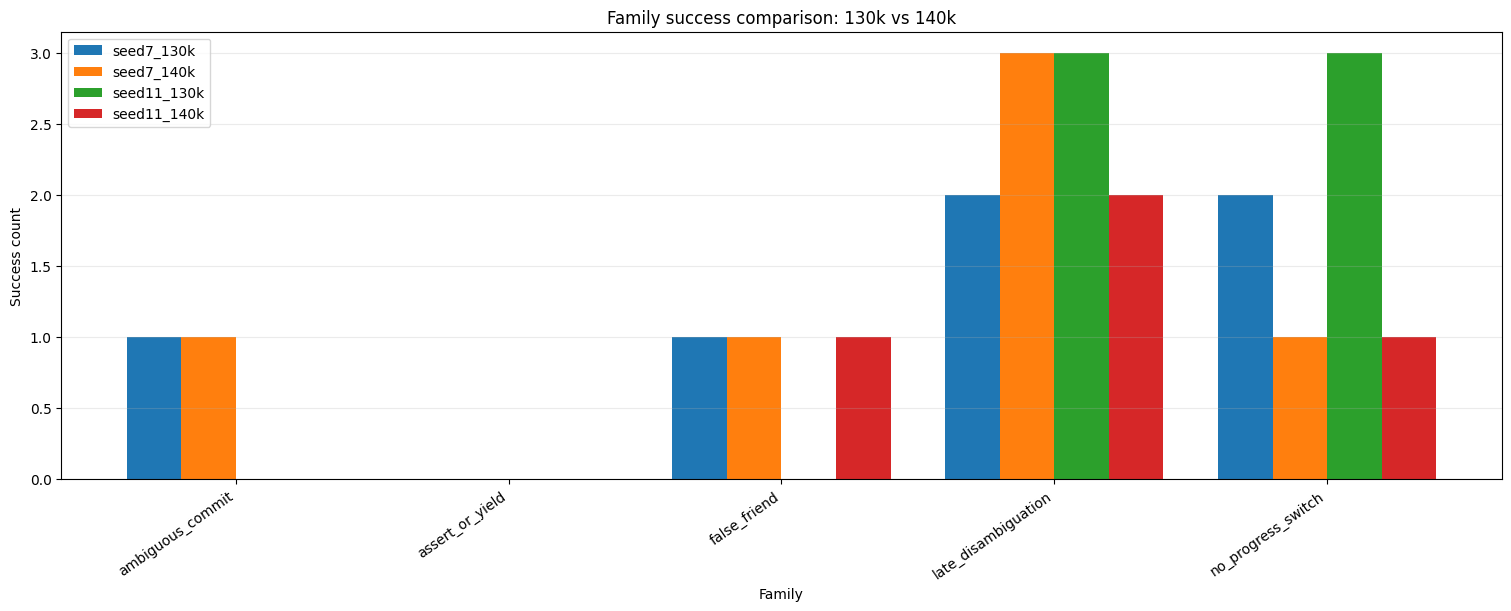

In [25]:
if plt is None or pd is None:
    display(Markdown("Install `matplotlib` and `pandas` to render the family success chart."))
else:
    family_df = pd.DataFrame(family_rows)
    families = family_df["family"].tolist()
    x_positions = range(len(families))
    width = 0.2

    fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)
    ax.bar([x - 1.5 * width for x in x_positions], family_df["seed7_130k_success"], width, label="seed7_130k")
    ax.bar([x - 0.5 * width for x in x_positions], family_df["seed7_140k_success"], width, label="seed7_140k")
    ax.bar([x + 0.5 * width for x in x_positions], family_df["seed11_130k_success"], width, label="seed11_130k")
    ax.bar([x + 1.5 * width for x in x_positions], family_df["seed11_140k_success"], width, label="seed11_140k")

    ax.set_title("Family success comparison: 130k vs 140k")
    ax.set_xlabel("Family")
    ax.set_ylabel("Success count")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(families, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best")
    display(fig)
    plt.close(fig)

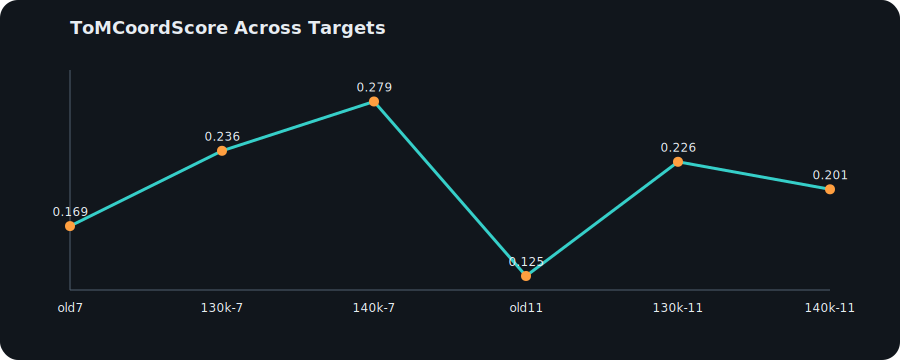

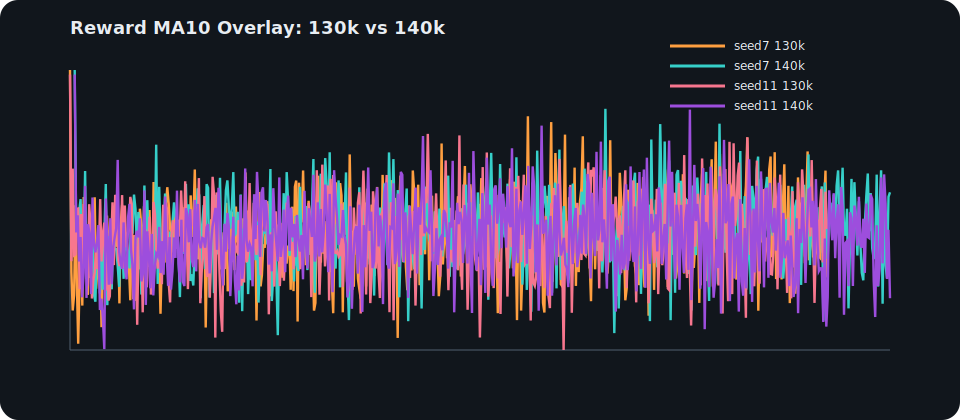

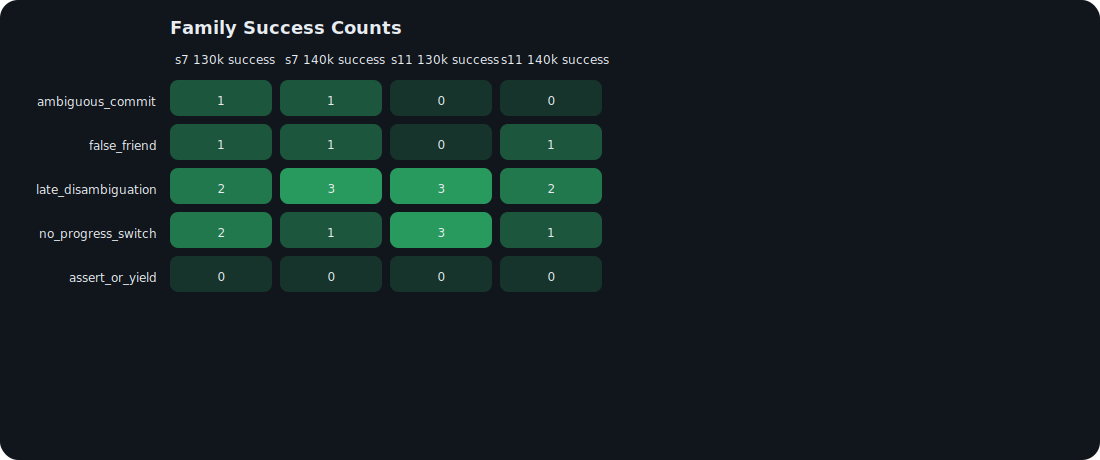

In [26]:
display_svg(REPORTS_140_ROOT / "longrun_metric_lines.svg")
display_svg(REPORTS_140_ROOT / "longrun_curve_overlay.svg")
display_svg(REPORTS_140_ROOT / "longrun_family_success.svg")


In [27]:
mean_130 = summary_130["branch_mean_metrics"]
mean_140 = summary_140["branch_mean_140k"]

delta_score = mean_140["ToMCoordScore"] - mean_130["ToMCoordScore"]
delta_success = mean_140["SuccessRate"] - mean_130["SuccessRate"]
delta_deadlock = mean_140["DeadlockRate"] - mean_130["DeadlockRate"]
delta_coord_eff = mean_140["CoordinationEfficiency"] - mean_130["CoordinationEfficiency"]

takeaways_140 = [
    "### 140k vs 130k quick read",
    f"- ToMCoordScore change (`140k-130k`): `{delta_score:+.3f}`.",
    f"- SuccessRate change (`140k-130k`): `{delta_success:+.3f}`.",
    f"- DeadlockRate change (`140k-130k`): `{delta_deadlock:+.3f}`.",
    f"- CoordinationEfficiency change (`140k-130k`): `{delta_coord_eff:+.3f}`.",
    "- Interpretation: 140k slightly increases score but weakens reliability metrics.",
]

display(Markdown("\n".join(takeaways_140)))

### 140k vs 130k quick read
- ToMCoordScore change (`140k-130k`): `+0.010`.
- SuccessRate change (`140k-130k`): `-0.050`.
- DeadlockRate change (`140k-130k`): `-0.050`.
- CoordinationEfficiency change (`140k-130k`): `-0.021`.
- Interpretation: 140k slightly increases score but weakens reliability metrics.

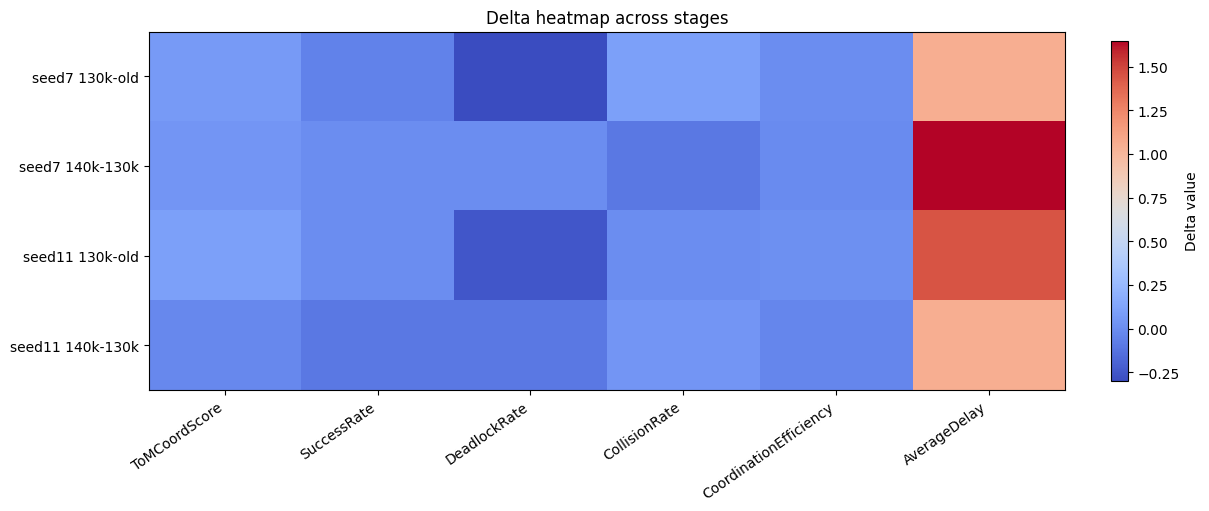

In [30]:
if plt is None or pd is None:
    display(Markdown("Install `matplotlib` and `pandas` to render heatmaps."))
else:
    delta_metrics = [
        "ToMCoordScore",
        "SuccessRate",
        "DeadlockRate",
        "CollisionRate",
        "CoordinationEfficiency",
        "AverageDelay",
    ]

    delta_rows = []
    for seed in SEEDS:
        old_metrics = old_selection[seed]["candidate_metrics"]
        m130 = run_130[seed]["eval_metrics"]
        m140 = run_140[seed]["eval_metrics"]
        delta_rows.append({
            "seed": f"seed{seed}",
            "stage": "130k-old",
            **{metric: m130[metric] - old_metrics[metric] for metric in delta_metrics},
        })
        delta_rows.append({
            "seed": f"seed{seed}",
            "stage": "140k-130k",
            **{metric: m140[metric] - m130[metric] for metric in delta_metrics},
        })

    delta_df = pd.DataFrame(delta_rows)
    row_labels = [f"{row['seed']} {row['stage']}" for _, row in delta_df.iterrows()]
    matrix = delta_df[delta_metrics].values

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    img = ax.imshow(matrix, aspect="auto", cmap="coolwarm")
    ax.set_title("Delta heatmap across stages")
    ax.set_xticks(range(len(delta_metrics)))
    ax.set_xticklabels(delta_metrics, rotation=35, ha="right")
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)

    colorbar = fig.colorbar(img, ax=ax, shrink=0.95)
    colorbar.set_label("Delta value")
    display(fig)
    plt.close(fig)

## Final Synthesis

This final cell turns the report packs into a concise recommendation view.


In [28]:
ranking_rows = []
for seed in SEEDS:
    ranking_rows.append({"seed": seed, "checkpoint": "old_auxhead_800", **old_selection[seed]["candidate_metrics"]})
    ranking_rows.append({"seed": seed, "checkpoint": "130k", **run_130[seed]["eval_metrics"]})
    ranking_rows.append({"seed": seed, "checkpoint": "140k", **run_140[seed]["eval_metrics"]})

best_row = max(ranking_rows, key=lambda row: row["ToMCoordScore"])
spread_130 = abs(run_130[7]["eval_metrics"]["ToMCoordScore"] - run_130[11]["eval_metrics"]["ToMCoordScore"])
spread_140 = abs(run_140[7]["eval_metrics"]["ToMCoordScore"] - run_140[11]["eval_metrics"]["ToMCoordScore"])
assert_or_yield_all_zero = all(
    summary_140[key]["assert_or_yield"]["success"] == 0
    for key in [
        "seed7_130k_family_outcomes",
        "seed7_140k_family_outcomes",
        "seed11_130k_family_outcomes",
        "seed11_140k_family_outcomes",
    ]
)

recommendation_lines = [
    "### Recommendation snapshot",
    f"- Best individual checkpoint: `seed{best_row['seed']} {best_row['checkpoint']}` with `ToMCoordScore={best_row['ToMCoordScore']:.3f}`.",
    f"- Safer cross-seed stopping point: `130k` (score spread `{spread_130:.3f}` vs `{spread_140:.3f}` at `140k`).",
    f"- Branch mean score does rise slightly at `140k` (`{summary_140['branch_mean_140k']['ToMCoordScore'] - summary_130['branch_mean_metrics']['ToMCoordScore']:+.3f}`), but it trades away success and coordination efficiency.",
    "- `late_disambiguation` remains the clearest strength family across the long-run checkpoints.",
    f"- `assert_or_yield` is still unresolved across all four long-run checkpoints: `{assert_or_yield_all_zero}`.",
]

display(Markdown("\n".join(recommendation_lines)))
display(Markdown("### Checkpoint ranking by ToMCoordScore"))

if pd is None:
    sorted(ranking_rows, key=lambda row: row["ToMCoordScore"], reverse=True)
else:
    pd.DataFrame(ranking_rows).sort_values("ToMCoordScore", ascending=False).set_index(["seed", "checkpoint"])


### Recommendation snapshot
- Best individual checkpoint: `seed7 140k` with `ToMCoordScore=0.279`.
- Safer cross-seed stopping point: `130k` (score spread `0.010` vs `0.078` at `140k`).
- Branch mean score does rise slightly at `140k` (`+0.010`), but it trades away success and coordination efficiency.
- `late_disambiguation` remains the clearest strength family across the long-run checkpoints.
- `assert_or_yield` is still unresolved across all four long-run checkpoints: `True`.

### Checkpoint ranking by ToMCoordScore

## Local 140k V2 Comparison

These cells read the new Variant 2 long-run report pack under `/Users/stephenbeale/Projects/ToM AI Research Team/modal/tom-140k-modal-results-v2/reports`.


In [ ]:
RESULTS_140_V2_ROOT = ROOT / "modal" / "tom-140k-modal-results-v2"
REPORTS_140_V2_ROOT = RESULTS_140_V2_ROOT / "reports"

display(Markdown(load_text(REPORTS_140_V2_ROOT / "modal_v2_140k_project_report.md")))
summary_140_v2 = load_json(REPORTS_140_V2_ROOT / "modal_v2_140k_summary.json")
summary_140_v2["verdicts"]


In [ ]:
display_svg(REPORTS_140_V2_ROOT / "v2_tom_score_lines.svg")
display_svg(REPORTS_140_V2_ROOT / "v2_curve_overlay.svg")
display_svg(REPORTS_140_V2_ROOT / "v2_family_success.svg")


## Variant 2 Local Visuals

This section loads the local Variant 2 analysis JSONs from `logs/local-run-v2-modal-seed7` and `logs/local-run-v2-modal-seed11`, then renders the PCA-style 3D figures and heatmaps, and exports polished PDF/SVG assets under `/Users/stephenbeale/Projects/ToM AI Research Team/modal/reports`.


In [ ]:
import importlib
import sys

UTILS_CANDIDATES = [ROOT / "notebooks", ROOT / "modal"]
for candidate in UTILS_CANDIDATES:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import variant2_visuals as v2v
importlib.reload(v2v)

try:
    v2_bundle = v2v.load_variant2_bundle(ROOT, seeds=tuple(SEEDS))
    display(Markdown("### Loaded Variant 2 visual bundle"))
    v2_bundle["scenario_df"].head()
except Exception as exc:
    v2_bundle = None
    display(Markdown(f"Variant 2 visuals unavailable: `{exc}`"))


In [ ]:
if v2_bundle is None:
    display(Markdown("Variant 2 PCA figure unavailable."))
else:
    fig = v2v.build_3d_pca_figure(v2_bundle)
    display(fig)
    plt.close(fig)


In [ ]:
if v2_bundle is None:
    display(Markdown("Variant 2 heatmaps unavailable."))
else:
    fig_panel = v2v.build_heatmap_panel(v2_bundle)
    display(fig_panel)
    plt.close(fig_panel)

    fig_regret = v2v.build_regret_heatmap(v2_bundle)
    display(fig_regret)
    plt.close(fig_regret)


In [ ]:
if v2_bundle is None:
    display(Markdown("Variant 2 side-by-side figure unavailable."))
else:
    fig = v2v.build_side_by_side_figure(v2_bundle)
    display(fig)
    plt.close(fig)


In [ ]:
if v2_bundle is None:
    display(Markdown("Variant 2 exports unavailable."))
else:
    export_paths = v2v.export_variant2_static(v2_bundle, include_rotation=False)
    display(Markdown("### Saved Variant 2 static exports"))
    export_paths

    # Optional later pass if you want the animated rotation too:
    # rotation_paths = v2v.export_variant2_static(v2_bundle, include_rotation=True)
    # rotation_paths
